# Planification de la production des verres

La compagnie Wyndor Glass Co. produit des produits verriers de haute qualité, incluant des fênetre et des portes vitrées. Elle dispose à cette fin de trois usines (usine 1, usine 2, usine 3) qui ont chacune une capacité de production limitée. Les châssis en aliminium et les matériaux sont produits dans l'usine 1, les châssis en bois sont fabriqués dans l'usine 2, et l'usine 3 produit le verre et assemble les produits. La compagnie a décidé de mettre en place de ligne de production:

- **produit 1**: une porte vitrée avec un châssis d'aliminium;
- **produit 2**: une fênetre double-critage avec châssis en bois.

Un lot de 20 unités donne lieu à un profit de 3000€ et 5000€, respectivement pour le produit 1 et le produit 2.
Chaque lot d'un produit est le résultat combiné de la production dans les trois usines.

**Variable de decision**:

$x_{1}$: une porte vitrée avec un chassis d'aluminium
$x_{2}$: une fênetre double-critage avec châssis en bois

**Formulation en tableau**:

| | Produit 1 (h) | Produit 2 (h)| Capacité de production (h) |
| ------ | ------ | ------ | ------ |
| Usine 1 | 1 | 0 | 4 |
| Usine 2 | 0 | 2 | 12 |
| Usine 3 | 3 | 2 | 18 |
| Production | 150 | 250 |  |

**Fonction objectif**: **max f(x) = 150$x_{1}$ + 250$x_{2}$**

On a l'equation suivant qui represente le tableau ci-dessus:
$$\left\{\begin{array}{c}1x_{1} + 0x_{2} \leq 4 \\ 0x_{1} + 2x_{2} \leq 12 \\ 3x_{1} + 2x_{2} \leq 18 \\ x_{1} \geq 0, x_{2} \geq 0\end{array}\right.$$

Sous forme matricielle cette système d'équation devient **Ax = b** avec 
$$A = \left(\begin{array}{cc}1 & 0 \\ 0 & 2 \\ 3 & 2\end{array}\right) \; , x = \left(\begin{array}{c}x_{1} \\ x_{2}\end{array}\right) \; et \; b = \left(\begin{array}{c}4 \\ 12 \\ 18\end{array}\right)$$

On a **max f($x_{1}, x_{2}$) = $c^{t}x$** où $c = \left(\begin{array}{c}150 \\ 250\end{array}\right)$

$\left\{\begin{array}{c}Ax \leq b \\ x \geq 0\end{array}\right.$

In [15]:
import numpy as np
from scipy.optimize import linprog

# fonction objectif : f(x1, x2) = 150x1 + 250x2
c = [-150, -250]

A = np.array([[1,0],[0,2],[3,2]])

# Les contraintes
b = np.array([4, 12, 18])

# x1 >= 0 et x2 >= 0
x_bounds = (0, None)

# Résolution
res = linprog(c, A_ub=A, b_ub=b, bounds=[x_bounds, x_bounds], method='highs')

# Affichage
print(f"Status : {res.message}")
print(f"Solution optimale : x1={res.x[0]:.2f} et x2={res.x[1]:.2f}")
print(f"Profit maximum : {-res.fun:.2f}")

Status : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Solution optimale : x1=2.00 et x2=6.00
Profit maximum : 1800.00


# Répresention graphique

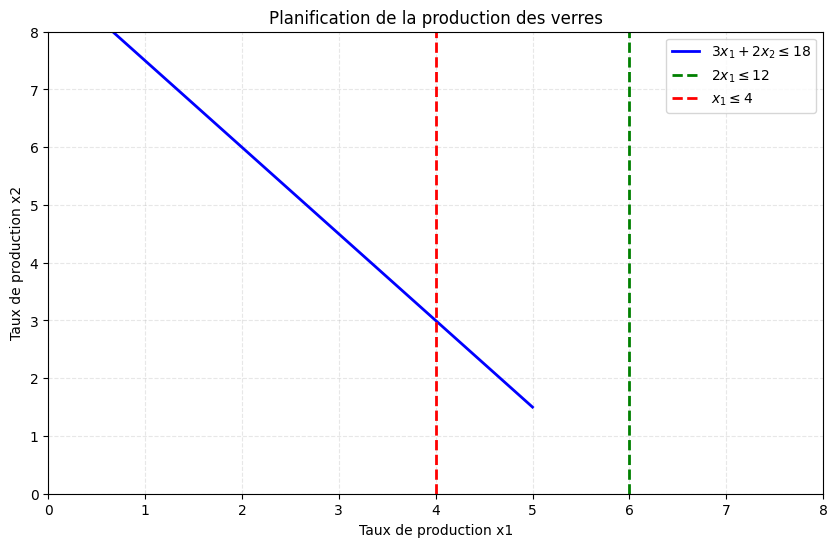

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt

x_vals = np.linspace(0, 5, 400)

def contraint1(x1):
    return (18 - 3 * x1)/2

sol_1, sol_2 = res.x

y_c1 = contraint1(x_vals)


plt.figure(figsize=(10,6))
plt.xlabel("Taux de production x1")
plt.ylabel("Taux de production x2")
plt.title("Planification de la production des verres")
plt.plot(x_vals, y_c1, label="$3x_{1} + 2x_{2} \leq 18$", color="blue", linewidth=2)
plt.axvline(x=6, label="$2x_{1} \leq 12$", color="green", linewidth=2, linestyle='--')
plt.axvline(x=4, label="$x_{1} \leq 4$", color="red", linewidth=2, linestyle='--')






plt.ylim(0, 8)
plt.xlim(0,8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()